# Generate main paper's Figure 2

## Notebook README

**Related publication**

If you utilize any portions of the code, results, or draw inspiration for your projects, please give proper credit by citing the published article below.

 - Title: Residual biomass to bio-based chemicals and plastics: ex-ante screening methodology for prioritizing high-impact substitutions
 - Authors: [Nicolas LIENART](https://orcid.org/0009-0001-3259-2819), [Thibaut LECOMPTE](https://orcid.org/0000-0001-9237-8454), [Lorie HAMELIN](https://orcid.org/0000-0001-9092-1900) 
 - Journal: Resources, Conservation and Recycling (RCR) - Elsevier
 - Doi: #todo
 - Code author: Nicolas LIENART
 - Git repository (Forge INRAE): https://forge.inrae.fr/nicolas.lienart/screen-lca-paper-supplementary-code
 - Git repository (GitHub): https://github.com/nicolnt/screen-lca-paper-supplementary-code

**Description and details**

This code generates the hotspot figure (Figure 2) showing the import and production amount of chemicals and plastics in the EU27, their unit GHG footprint (cradle-to-gate), the total estimated footprint (cradle-to-gate) and the estimated end of life impacts. Refer to the aforementioned main manuscript and accompanying supplementary information documents for more details.

Note that the figure is post-treated using Inkscape open-source vector graphic design software to improve the visual and readability. Doing everything in Python goes outside our knowledge of the Matplotlib library. Nonetheless, our code generates the main structure and most of the features.

**Updates**

 - August 16, 2026: Separated figure generation from footprint data calculation.

**Package versions**

 - See [`environment.yml`](./environment.yml)

**Relevant references**

ChatGPT was used to help with the SVG post-treatment before Inkscape final touch.

- Prompts:
  - `Using matplotlib, I want to export the figure as a svg. But instead of each bars of each plt.bar having a name as "patch_xx" and containing "pathxx", where xx are digits, I want it to have meaningful names, based on dataframe data and index. How shoul I proceed?`
  - `How can I put all bars in "ax.bar" in a same parent svg group, also named.`
  - `This does not work, I get the following error: AttributeError: 'BarContainer' object has no attribute 'set_gid'`
  - `How can I make pyplot to stop putting single paths in groups when exporting to svg?`
  - `Using XPath syntax, how do I select all groups that are in the group with id="hello"`
- Public link: https://chatgpt.com/share/693bf85f-d4bc-8009-9538-189cdfdd7e83

**Licence**

This work is licenced under the Creative Commons Attribution (CC-BY 4.0) public licence.

## Initialization

### Python imports

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import xml.etree.ElementTree as ET
import re
import pandas as pd
from importlib.metadata import version

In [3]:
print('matplotlib:', version('matplotlib'))
print('pandas:', version('pandas'))

matplotlib: 3.10.9
pandas: 2.2.3


### Manually set other global variables

In [4]:
UNIT_EOL_FOOTPRINT_COLUMN_NAME = 'Unit impact of end-of-life (kg CO2/kg)'
UNIT_FOOTPRINT_WITHOUT_EOL_COLUMN_NAME = "Unit GHG footprint without end-of-life (IPCC 2021 GWP100, kg CO2e/kg)"
UNIT_FOOTPRINT_WITH_EOL_COLUMN_NAME = "Unit GHG footprint with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)"
TOTAL_FOOTPRINT_WITHOUT_EOL_COLUMN_NAME = "Total GHG footprint without end-of-life (IPCC 2021 GWP100, kg CO2e/kg)"
TOTAL_FOOTPRINT_WITH_EOL_COLUMN_NAME = "Total GHG footprint with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)"
QUANTITY_COLUMN_NAME = "Quantity (Mt/yr)"
UNIT_BTX_FOOTPRINT_COLUMN_NAME = "Unit GHG footprint of BTX (IPCC 2021 GWP100, kg CO2e/kg)"
OUTPUT_PRODUCT_CODE_COLUMN_NAME = "Total footprint rank"
ECOINVENT_ACTIVITY_COLUMN_NAME = "Ecoinvent activity name or proxy"
UNIT_FOOTPRINT_LOCAL_PRODUCTION_COLUMN_NAME = "Unit GHG footprint of local production share (IPCC 2021 GWP100, kg CO2e/kg)"
LOCAL_PRODUCTION_SHARE_COLUMN_NAME = "Local production share of available quantity (%)"

ECOINVENT_DATABASE_NAMES = ['ecoinvent-3.11-cutoff', 'ecoinvent-3.12-cutoff']

FIGURE_N_TOP_HOTSPOT_PRODUCTS = 15

ECOINVENT_VERSION = ECOINVENT_DATABASE_NAMES[1]

In [4]:
# NOTE: Name corresponds to Ecoinvent's product name
SUBSTANCE_LIST = [
    {
        "name":'propylene',
        "CAS":'115-07-1'
    },
    {
        "name":'ethylene',
        "CAS":'74-85-1'
    },
    {
        "name":'methanol',
        "CAS":'000067-56-1'
    },
    {
        "name":'xylene, mixed',
        "CAS":'',
        "type": "BTX"
    },
    {
        "name":'o-xylene',
        "CAS":'95-47-6',
        "type": "BTX"
    },
    {
        "name":'p-xylene',
        "CAS":'106-42-3',
        "type": "BTX"
    },
    {
        "name":'toluene, liquid',
        "CAS":'108-88-3',
        "type": "BTX"
    },
    {
        "name":'benzene',
        "CAS":'000071-43-2',
        "type": "BTX"
    }
]

## Create figure

### Import data

In [5]:
# NOTE: Import CSV from already exported data
hotspot_products_processed_df = pd.read_csv('../Output_data/Hotspot products with footprint - processed.csv')

# NOTE: Remove unused columns from the CSV. List columns to remove
hotspot_products_to_figure_df = hotspot_products_processed_df.loc[:, ~hotspot_products_processed_df.columns.isin(
    [
        'PRODCOM code',
        'Carbon atoms',
        'Molecular weight (MW)'
    ]
    +
    [f"{substance['name']} - {ECOINVENT_DATABASE_NAMES[0]}" for substance in SUBSTANCE_LIST if substance.get('type') == "BTX"]
    +
    [f"{substance['name']} - {ECOINVENT_DATABASE_NAMES[1]}" for substance in SUBSTANCE_LIST if substance.get('type') == "BTX"]
    )].copy()

### Figure functions

In [6]:
def add_labels_total_impact(ax, x, quantity, y, amount, id):
    for i in range(len(x)):
        gid = f"annotation_total_{id[i]}_{i}"  # create any naming scheme you like
        ax.annotate(text=f'{round(amount[i], 1)}',
                    xy=(x[i] + quantity[i]/2, y[i]),
                    rotation=0,
                    horizontalalignment='center',
                    verticalalignment='baseline',
                    rotation_mode='default',
                    fontsize=13,
                    gid=gid)  # Aligning text at center
        
        #bar.set_gid(gid)
        #plt.text(i, y[i], y[i], ha='center')  # Aligning text at center

In [7]:
def add_labels_quantities(ax, x, quantity, amount, id):
    for i in range(len(x)):
        gid = f"annotation_quantity_{id[i]}_{i}"  # create any naming scheme you like
        ax.annotate(text=f'{round(amount[i], 1)}',
                    xy=(x[i] + quantity[i]/2, -1),
                    # rotation=45,
                    horizontalalignment='center',
                    verticalalignment='baseline',
                    rotation_mode='default',
                    fontsize=13,
                    # fontweight='medium',
                    # fontstyle='italic',
                    gid=gid)  # Aligning text at center
        
        #bar.set_gid(gid)
        #plt.annotate(text=f'{round(label[i], 1)} Mt', xy=(x[i] + quantity[i]/2, -0.2), rotation=0,
        #plt.text(i, y[i], y[i], ha='center')  # Aligning text at center

In [8]:
def add_labels_code(ax, x, y, quantity, value, id):
    for i in range(len(x)):
        gid = f"annotation_id_{id[i]}_{i}"  # create any naming scheme you like
        ax.annotate(text=value[i],
                    xy=(x[i] + quantity[i]/2, y[i]+0.5),
                    rotation=0,
                    horizontalalignment='center',
                    verticalalignment='baseline',
                    rotation_mode='default',
                    fontsize=13,
                    gid=gid)  # Aligning text at center

In [9]:
def add_labels_name(ax, x, y, quantity, name, id):
    for i in range(len(x)):
        gid = f"annotation_id_{id[i]}_{i}"  # create any naming scheme you like
        ax.annotate(text=name[i],
                    xy=(x[i] + quantity[i]/2, y[i]+0.5),
                    rotation=0,
                    horizontalalignment='center',
                    verticalalignment='baseline',
                    rotation_mode='default',
                    fontsize=13,
                    gid=gid)  # Aligning text at center

In [10]:
def add_labels_unit_impact(ax, x, y, quantity, amount, id):
    for i in range(len(x)):
        gid = f"annotation_unit_impact_{id[i]}_{i}"  # create any naming scheme you like
        ax.annotate(text=f'{round(amount[i], 1)}',
                    xy=(x[i] + quantity[i]/2, y[i]+0.5),
                    rotation=0,
                    horizontalalignment='center',
                    verticalalignment='baseline',
                    rotation_mode='default',
                    fontsize=8,
                    gid=gid)  # Aligning text at center

### Generate figure

<function matplotlib.pyplot.show(close=None, block=None)>

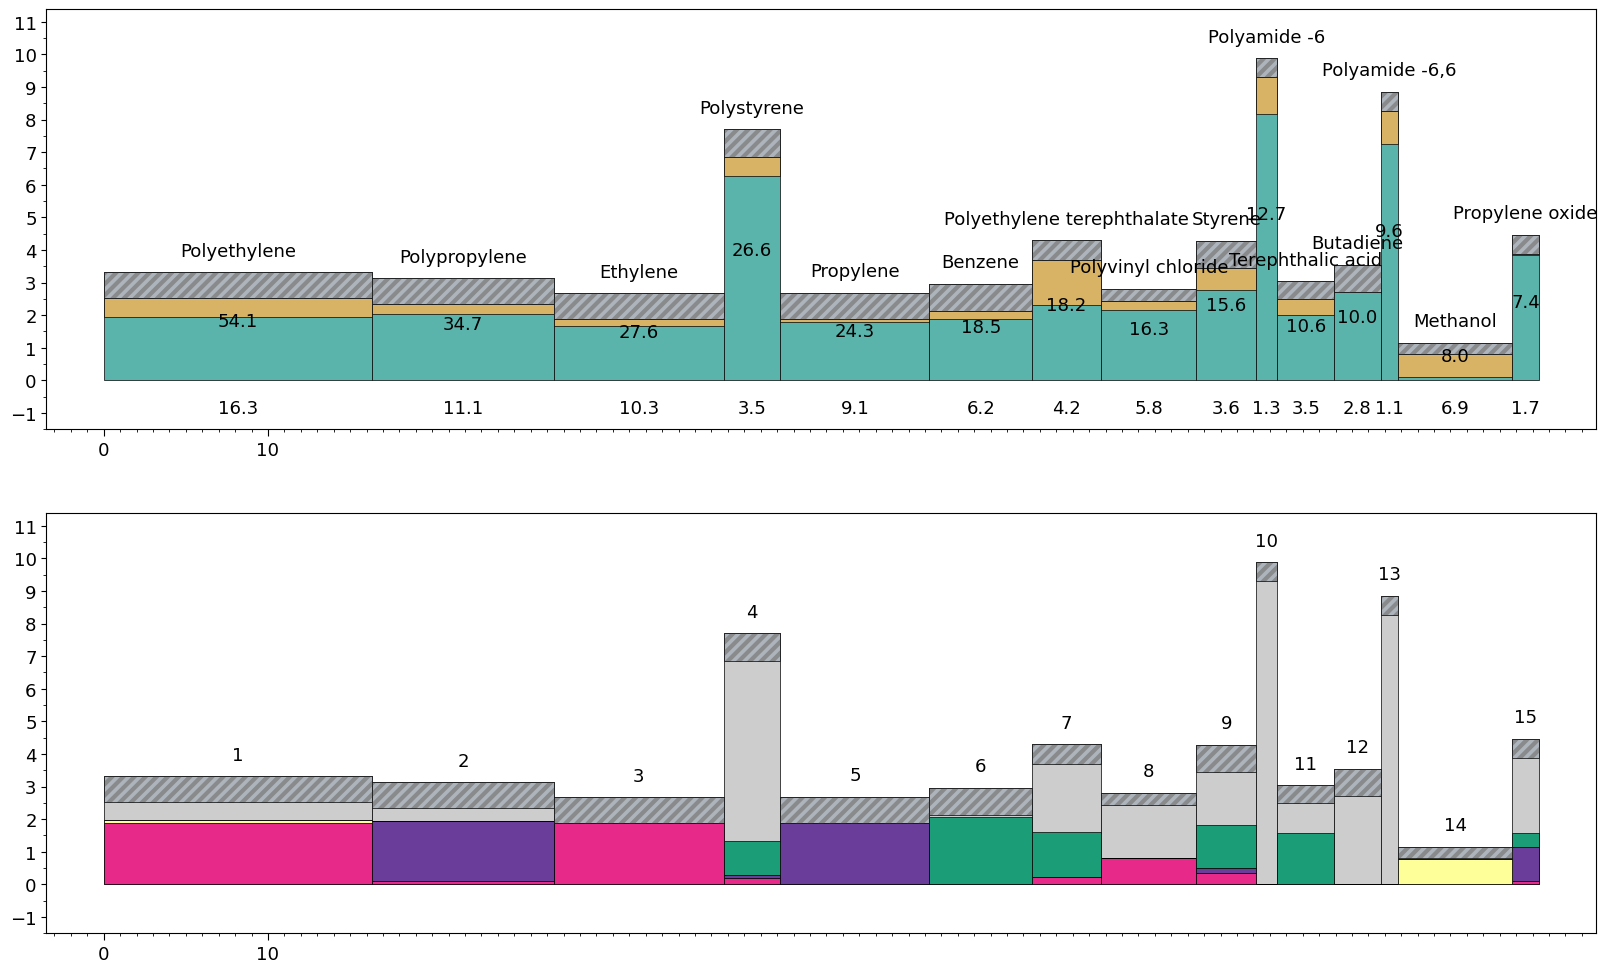

In [ ]:
# color_palette = ["#9aa6b6", "#d81b60", '#1e88e5','#ffc107','#004d40','#9aa6b6']

# https://colorbrewer2.org/#type=qualitative&scheme=Paired&n=11
color_palette = {
    'local_production': "#5ab4ac",
    'import': "#d8b365",
    # 'ethylene': "#d81b60",
    # 'propylene': '#1e88e5',
    # 'methanol': '#ffc107',
    # 'btx': '#004d40',
    # 'ethylene': "#ffff99",
    # 'propylene': '#beaed4',
    # 'methanol': '#fdc086',
    # 'btx': '#7fc97f',
    'ethylene': "#e7298a",
    'propylene': '#6a3d9a',
    'methanol': '#ffff99',
    'btx': '#1b9e77',
    'production_import_rest': "#CDCDCD",
    
    # 'eol': '#9aa6b6',
    # 'eol_hatch': '#74787c',
    'eol': "#adb4bc",
    'eol_hatch': "#888A8B",
    }

unit_footprint_with_eol_column_name = f"{UNIT_FOOTPRINT_WITH_EOL_COLUMN_NAME} - {ECOINVENT_VERSION}"
unit_footprint_without_eol_column_name = f"{UNIT_FOOTPRINT_WITHOUT_EOL_COLUMN_NAME} - {ECOINVENT_VERSION}"
unit_btx_column_name = f"{UNIT_BTX_FOOTPRINT_COLUMN_NAME} - {ECOINVENT_VERSION}"
total_footprint_without_eol_column_name = f"{TOTAL_FOOTPRINT_WITHOUT_EOL_COLUMN_NAME} - {ECOINVENT_VERSION}"
total_footprint_with_eol_column_name = f"{TOTAL_FOOTPRINT_WITH_EOL_COLUMN_NAME} - {ECOINVENT_VERSION}"
local_production_footprint_column_name = f"{UNIT_FOOTPRINT_LOCAL_PRODUCTION_COLUMN_NAME} - {ECOINVENT_VERSION}"
ethylene_footprint_column_name = f"ethylene - {ECOINVENT_VERSION}"
propylene_footprint_column_name = f"propylene - {ECOINVENT_VERSION}"
methanol_footprint_column_name = f"methanol - {ECOINVENT_VERSION}"
unit_eol_footprint_column_name = f"{UNIT_EOL_FOOTPRINT_COLUMN_NAME} - {ECOINVENT_VERSION}"

# NOTE: Sort data by decreasing order of total GHG footprint with end-of-life
hotspot_products_to_figure_df = hotspot_products_processed_df.nlargest(n=FIGURE_N_TOP_HOTSPOT_PRODUCTS, columns=[total_footprint_with_eol_column_name]).sort_values(by=[total_footprint_with_eol_column_name], ascending=False, ignore_index=True).copy()

# NOTE: Add a rank, autoincremented from 1 for the product with the highest footprint
hotspot_products_to_figure_df[OUTPUT_PRODUCT_CODE_COLUMN_NAME] = range(1, 1 + len(hotspot_products_to_figure_df))

vertical_padding = 1.5
horizontal_padding = 0.04
top_y_limit = hotspot_products_to_figure_df.nlargest(1, unit_footprint_with_eol_column_name).iloc[0][unit_footprint_with_eol_column_name] + vertical_padding

# NOTE: Calculate x axis value to position product bars horizontally in the figure
hotspot_products_processed_df['x_axis'] = float('nan')

for hotspot_product_index, hotspot_product in hotspot_products_to_figure_df.iterrows():
    if hotspot_product_index == 0:
        x_value = 0
    else:
        x_value = hotspot_products_to_figure_df.loc[hotspot_product_index-1]['x_axis'] + hotspot_products_to_figure_df.loc[hotspot_product_index-1][QUANTITY_COLUMN_NAME]

    hotspot_products_to_figure_df.at[hotspot_product_index,'x_axis'] = x_value

# NOTE: Generate figure

figure = plt.figure(figsize=(20, 12))
plt.rcParams['svg.fonttype'] = 'none'
# setting font size
plt.rcParams.update({'font.size': 13})
(ax_1, ax_2) = figure.subplots(2, 1)
#plt.tight_layout()

# NOTE: Bottom subplot

total_bars = ax_2.bar(x=hotspot_products_to_figure_df['x_axis'],
                      height=hotspot_products_to_figure_df[unit_footprint_with_eol_column_name], width=hotspot_products_to_figure_df[QUANTITY_COLUMN_NAME],
                      align='edge', edgecolor = 'k', linewidth = 0.5, color=color_palette['production_import_rest'])
# NOTE: Name bars
for bar, (idx, row) in zip(total_bars, hotspot_products_to_figure_df.iterrows()):
    gid = f"bar_totalaxes2_{row['Figure name']}_{idx}"
    bar.set_gid(gid)

ethylene_bars = ax_2.bar(x=hotspot_products_to_figure_df['x_axis'],
                        #  bottom=hotspot_products_to_figure_df[UNIT_EOL_FOOTPRINT_COLUMN_NAME],
                         height=hotspot_products_to_figure_df[ethylene_footprint_column_name],
                         width=hotspot_products_to_figure_df[QUANTITY_COLUMN_NAME], 
                         align='edge', edgecolor = 'k', linewidth = 0.5, color=color_palette['ethylene'])
# NOTE: Name bars
for bar, (idx, row) in zip(ethylene_bars, hotspot_products_to_figure_df.iterrows()):
    gid = f"bar_ethylene_{row['Figure name']}_{idx}"
    bar.set_gid(gid)

propylene_bars = ax_2.bar(x=hotspot_products_to_figure_df['x_axis'],
                          bottom=hotspot_products_to_figure_df[ethylene_footprint_column_name],
                          height=hotspot_products_to_figure_df[propylene_footprint_column_name],
                          width=hotspot_products_to_figure_df[QUANTITY_COLUMN_NAME],
                          align='edge', edgecolor = 'k', linewidth = 0.5, color=color_palette['propylene'])
# NOTE: Name bars
for bar, (idx, row) in zip(propylene_bars, hotspot_products_to_figure_df.iterrows()):
    gid = f"bar_propylene_{row['Figure name']}_{idx}"  # create any naming scheme you like
    bar.set_gid(gid)

methanol_bars = ax_2.bar(x=hotspot_products_to_figure_df['x_axis'],
                         bottom=hotspot_products_to_figure_df[ethylene_footprint_column_name]+hotspot_products_to_figure_df[propylene_footprint_column_name],
                         height=hotspot_products_to_figure_df[methanol_footprint_column_name],
                         width=hotspot_products_to_figure_df[QUANTITY_COLUMN_NAME],
                         align='edge', edgecolor = 'k', linewidth = 0.5, color=color_palette['methanol'])
# NOTE: Name bars
for bar, (idx, row) in zip(methanol_bars, hotspot_products_to_figure_df.iterrows()):
    gid = f"bar_methanol_{row['Figure name']}_{idx}"  # create any naming scheme you like
    bar.set_gid(gid)

btx_bars = ax_2.bar(x=hotspot_products_to_figure_df['x_axis'],
                    bottom=hotspot_products_to_figure_df[ethylene_footprint_column_name]+hotspot_products_to_figure_df[propylene_footprint_column_name]+hotspot_products_to_figure_df[methanol_footprint_column_name],
                    height=hotspot_products_to_figure_df[unit_btx_column_name],
                    width=hotspot_products_to_figure_df[QUANTITY_COLUMN_NAME],
                    align='edge', edgecolor = 'k', linewidth = 0.5, color=color_palette['btx'])
# NOTE: Name bars
for bar, (idx, row) in zip(btx_bars, hotspot_products_to_figure_df.iterrows()):
    gid = f"bar_btx_{row['Figure name']}_{idx}"  # create any naming scheme you like
    bar.set_gid(gid)

eol_bars_ax_2 = ax_2.bar(x=hotspot_products_to_figure_df['x_axis'],
                    bottom=hotspot_products_to_figure_df[unit_footprint_with_eol_column_name]-hotspot_products_to_figure_df[unit_eol_footprint_column_name],
                    height=hotspot_products_to_figure_df[unit_eol_footprint_column_name],
                    width=hotspot_products_to_figure_df[QUANTITY_COLUMN_NAME],
                    align='edge', edgecolor = 'k', linewidth = 0.5, color=color_palette['eol'], hatch='///')
# NOTE: Name bars
for bar, (idx, row) in zip(eol_bars_ax_2, hotspot_products_to_figure_df.iterrows()):
    gid = f"bar_eol_{row['Figure name']}_{idx}"  # create any naming scheme you like
    bar.set_gid(gid)


ax_2.set_ylim(bottom=-vertical_padding, top=top_y_limit)
ax_2.margins(x=horizontal_padding)
#ax.set_xlim(left=0, right=70000)
ax_2.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax_2.xaxis.set_major_locator(ticker.FixedLocator([0, 10]))

ax_2.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax_2.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))

ax_2.tick_params(axis='x', which='major', length=5)
#ax_2.set_ymargin(1)

# NOTE: Top subplot

ax_1.set_ylim(bottom=-vertical_padding, top=top_y_limit)
ax_1.margins(x=horizontal_padding)
#ax.set_xlim(left=0, right=70000)
ax_1.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax_1.xaxis.set_major_locator(ticker.FixedLocator([0, 10]))

ax_1.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax_1.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))

ax_1.tick_params(axis='x', which='major', length=5)


total_bars_ax_1 = ax_1.bar(x=hotspot_products_to_figure_df['x_axis'], height=hotspot_products_to_figure_df[unit_footprint_with_eol_column_name],
                           width=hotspot_products_to_figure_df[QUANTITY_COLUMN_NAME], align='edge', edgecolor = 'k', linewidth = 0.5,
                           color=color_palette['local_production'])
# NOTE: Name bars
for bar, (idx, row) in zip(total_bars_ax_1, hotspot_products_to_figure_df.iterrows()):
    gid = f"bar_totalaxes1_{row[OUTPUT_PRODUCT_CODE_COLUMN_NAME]}_{idx}"  # create any naming scheme you like
    bar.set_gid(gid)

imported_production_bars = ax_1.bar(x=hotspot_products_to_figure_df['x_axis'],
                    bottom=hotspot_products_to_figure_df[local_production_footprint_column_name],
                    height=hotspot_products_to_figure_df[unit_footprint_without_eol_column_name]-hotspot_products_to_figure_df[local_production_footprint_column_name],
                    width=hotspot_products_to_figure_df[QUANTITY_COLUMN_NAME],
                    align='edge', edgecolor = 'k', linewidth = 0.5, color=color_palette['import'])
# NOTE: Name bars
for bar, (idx, row) in zip(imported_production_bars, hotspot_products_to_figure_df.iterrows()):
    gid = f"bar_local_production_{row['Figure name']}_{idx}"  # create any naming scheme you like
    bar.set_gid(gid)

eol_bars_ax_1 = ax_1.bar(x=hotspot_products_to_figure_df['x_axis'],
                    bottom=hotspot_products_to_figure_df[unit_footprint_with_eol_column_name]-hotspot_products_to_figure_df[unit_eol_footprint_column_name],
                    height=hotspot_products_to_figure_df[unit_eol_footprint_column_name],
                    width=hotspot_products_to_figure_df[QUANTITY_COLUMN_NAME],
                    align='edge', edgecolor='k', linewidth = 0.5, color=color_palette['eol'], hatch='///')
# NOTE: Name bars
for bar, (idx, row) in zip(eol_bars_ax_1, hotspot_products_to_figure_df.iterrows()):
    gid = f"bar_eol_{row['Figure name']}_{idx}"  # create any naming scheme you like
    bar.set_gid(gid)

# Source : 12-08-2026 - https://stackoverflow.com/questions/38168948/how-to-decouple-hatch-and-edge-color-in-matplotlib/78749098#78749098
for bc in eol_bars_ax_1 + eol_bars_ax_2:
    bc._hatch_color = matplotlib.colors.to_rgba(color_palette['eol_hatch'])
    bc._hatch_linewidth = 3
    bc.stale = True


add_labels_total_impact(ax=ax_1, x=hotspot_products_to_figure_df['x_axis'], quantity=hotspot_products_to_figure_df[QUANTITY_COLUMN_NAME], y=hotspot_products_to_figure_df[unit_footprint_with_eol_column_name]/2,
                        amount=hotspot_products_to_figure_df[total_footprint_with_eol_column_name], id=hotspot_products_to_figure_df['Figure name'])
add_labels_quantities(ax=ax_1, x=hotspot_products_to_figure_df['x_axis'], quantity=hotspot_products_to_figure_df[QUANTITY_COLUMN_NAME],
                      amount=hotspot_products_to_figure_df[QUANTITY_COLUMN_NAME], id=hotspot_products_to_figure_df['Figure name'])
#add_labels_unit_impact(ax=ax_2, x=output_table['x_axis'], quantity=output_table['Quantity'], y=output_table['unit impact'], amount=output_table['unit impact'], id=output_table['PRCCODE (Labels)'])

add_labels_code(ax=ax_2, x=hotspot_products_to_figure_df['x_axis'], quantity=hotspot_products_to_figure_df[QUANTITY_COLUMN_NAME], y=hotspot_products_to_figure_df[unit_footprint_with_eol_column_name],
              value=hotspot_products_to_figure_df[OUTPUT_PRODUCT_CODE_COLUMN_NAME], id=hotspot_products_to_figure_df['Figure name'])

add_labels_name(ax=ax_1, x=hotspot_products_to_figure_df['x_axis'], quantity=hotspot_products_to_figure_df[QUANTITY_COLUMN_NAME], y=hotspot_products_to_figure_df[unit_footprint_with_eol_column_name],
              name=hotspot_products_to_figure_df['Figure name'], id=hotspot_products_to_figure_df['Figure name'])

# NOTE: Save figure to file
plt.savefig(f"../Output_data/Figure 2/figure top {FIGURE_N_TOP_HOTSPOT_PRODUCTS} - {ECOINVENT_VERSION}.svg")

plt.show

## Figure post-treatment

In [ ]:
# Source : 27-10-2025 - https://chatgpt.com/share/6a85e387-3b68-83eb-ba2d-5cade909201e
# 3) Parse SVG and create a group wrapping the bars
# Note: the SVG has a default namespace; we handle it explicitly.
SVG_NS = "http://www.w3.org/2000/svg"
NS = {"svg": SVG_NS}
ET.register_namespace("", SVG_NS)  # preserve default namespace on write

tree = ET.parse(f"../Output_data/Figure 2/figure top {FIGURE_N_TOP_HOTSPOT_PRODUCTS} - {ECOINVENT_VERSION}.svg")

In [6]:
def postProcessSVG(root, axes_list=['axes_1', 'axes_2']):
    for axes in axes_list:
        axes_element = root.find(f".//svg:g[@id='{axes}']", NS)

        element_list = [e.get('id') for e in axes_element.findall(".//svg:g[@id]", NS)]
        patterns = []
        r = re.compile("^(.*?_.*?)_.*")

        for el in element_list:
            match = r.match(el)
            if match and match.group(1):
                pattern_group = match.group(1)
                patterns.append(pattern_group)

        patterns = list(reversed(list(set(patterns))))

        for pattern in patterns:
        
            # Find all elements that are bar paths/rects by id pattern "bar_..."
            # They might be <path> or <rect> depending on style/backend
            bar_elems = []
            for elem in axes_element.findall(".//svg:g", NS):
                eid = elem.get("id")
                if eid and eid.startswith(pattern):
                    bar_elems.append(elem)
            
            if not bar_elems:
                raise RuntimeError("No elements found with id starting 'bar_'. \
                                   Check the GIDs on bars and the SVG content.")
            else:
                bar_elems

            # Find where to insert the group: common place is as a child of the main <g> that contains axes.
            # We'll insert the new group as a child of the root SVG for simplicity.
            svg_group_element = ET.Element(f"{{{SVG_NS}}}g", {"id": f"group_{pattern}"})

            # Move each bar element into the new group.
            # Removing from the original parent requires finding that parent.
            def find_parent(root_node, child):
                for p in root_node.iter():
                    for c in p:
                        if c is child:
                            return p
                return None

            for e in bar_elems:
                parent = axes_element.find(f".//svg:g[@id='{e.get('id')}']/..", NS)
                # parent = find_parent(root, e)
                if parent is None:
                    continue
                parent.remove(e)
                svg_group_element.append(e)

            # Insert group into root (or into a suitable parent if you prefer)
            axes_element.append(svg_group_element)

In [7]:
# Source : 27-10-2025 - https://chatgpt.com/c/68ff4810-10a4-832e-b90a-33369191ba4c
def flatten(node):
    """Remove <g> elements that only contain a single child and no attributes."""
    for child in list(node):
        flatten(child)
    # If a <g> has only one child and no attributes other than id, flatten it
    for g in list(node.findall(f"{{{SVG_NS}}}g")):
        children = list(g)
        attrs = {k: v for k, v in g.attrib.items() if k != "id"}
        if len(children) == 1 and not attrs:
            child = children[0]
            if "id" in g.attrib and "id" not in child.attrib:
                child.attrib["id"] = g.attrib["id"]
            node.insert(list(node).index(g), child)
            node.remove(g)

In [8]:
root = tree.getroot()
postProcessSVG(root)
flatten(root)

In [ ]:
# 4) Write out modified SVG
export_tree = ET.ElementTree(root)
grouped_figure_file = f"../Output_data/Figure 2/grouped_figure top {FIGURE_N_TOP_HOTSPOT_PRODUCTS} - {ECOINVENT_VERSION}.svg"

export_tree.write(grouped_figure_file, encoding="utf-8", xml_declaration=True)

print(f"Saved {grouped_figure_file} with <g id='group_series1'> containing bar_* elements.")

Saved ../Output_data/grouped_figure top 15 - ecoinvent-3.12-cutoff.svg with <g id='group_series1'> containing bar_* elements.
